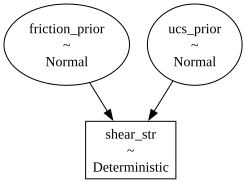

Model initialized successfully.
[ucs_prior, friction_prior]


In [ ]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

#print(f"PyMC Version: {pm.__version__}")


# no variables can exist isolated
# they must be a part of a computational graph/be a node

with pm.Model() as basic_rock_model:
    # priors/stochastic variables
    ucs_prior= pm.Normal("ucs_prior", mu=50.0, sigma=10.0)

    # string same as var
    # string is what pymc calls it, var is what py calls it, if not same, cant trace errors


    friction_prior = pm.Normal("friction_prior", mu=30.0, sigma=5.0)
    # simplified for now instead of beta

    # simple maths must be tracked by pymc; deterministic variable

    shear_str = pm.Deterministic("shear_str", ucs_prior + friction_prior*2.0)
    display(pm.model_to_graphviz(basic_rock_model))
    # print forces py to return objects __str__


# We haven't "run" the model, but we can look at it.
print("Model initialized successfully.")
print(basic_rock_model.basic_RVs)
#This lists the raw stochastic nodes PyMC is currently tracking.



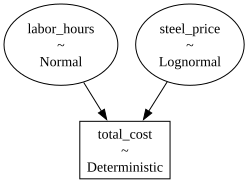

In [ ]:
with pm.Model() as tunnel_cost_model:
    # defining our priors
     # i expect these variables to follow this distro tentatively
    steel_price = pm.Lognormal("steel_price", mu = 2, sigma=0.4)
    labor_hours = pm.Normal("labor_hours", mu=1000, sigma=100)

    total_cost = pm.Deterministic("total_cost", steel_price+labor_hours*500) # 500 rs per hour

    display(pm.model_to_graphviz(tunnel_cost_model))


     # dag = directed acyclic graph